**MODEL 1 :VGG16**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

In [ ]:
# Directories for training and testing data
train_dir = '/content/drive/MyDrive/MRI/Training/'
test_dir = '/content/drive/MyDrive/MRI/Testing/'

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

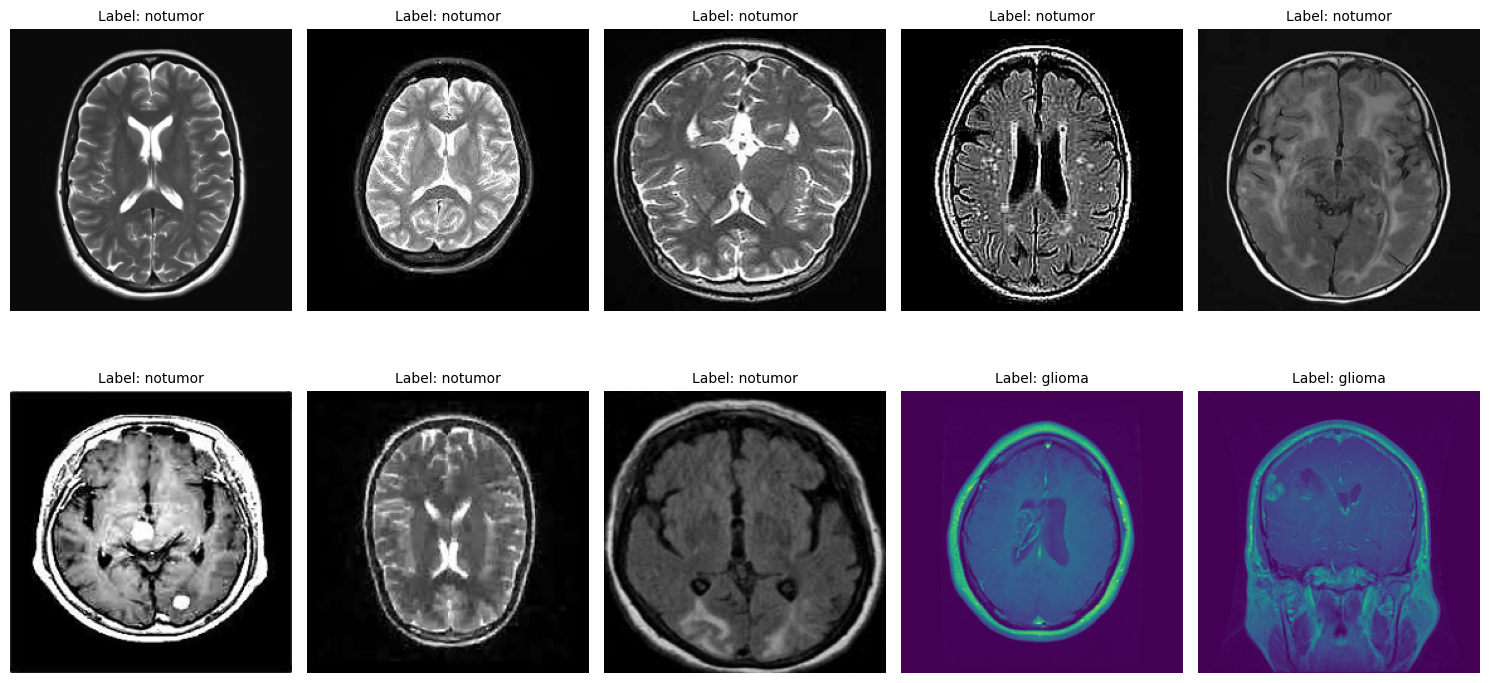

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide axis
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

In [ ]:
# Model architecture
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 5

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 578s 4s/step - loss: 0.1022 - sparse_categorical_accuracy: 0.9594
Epoch 2/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - loss: 0.0368 - sparse_categorical_accuracy: 0.9880
Epoch 3/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - loss: 0.0234 - sparse_categorical_accuracy: 0.9937
Epoch 4/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - loss: 0.0161 - sparse_categorical_accuracy: 0.9947
Epoch 5/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - loss: 0.0156 - sparse_categorical_accuracy: 0.9951


In [ ]:
# Save the entire model
model.save('model.h5')

In [ ]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('model.h5')

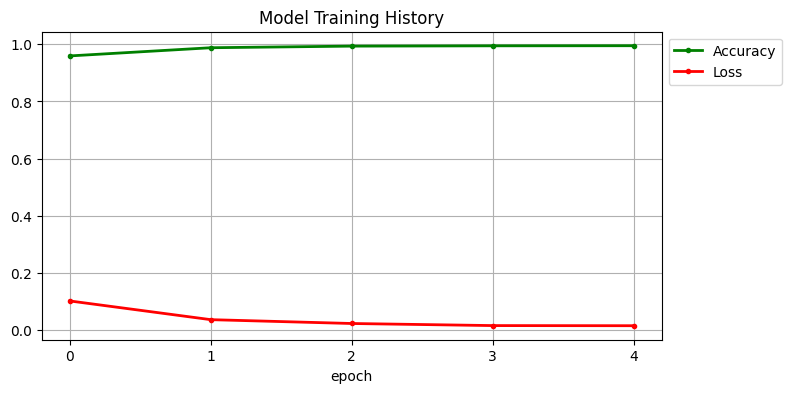

In [ ]:

plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       306
           1       0.76      1.00      0.87       405
           2       0.62      0.99      0.76       300

    accuracy                           0.69      1011
   macro avg       0.46      0.66      0.54      1011
weighted avg       0.49      0.69      0.57      1011



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import accuracy_score


y_pred = np.argmax(test_predictions, axis=1)


y_true = test_labels_encoded

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy: {:.2f}%".format(accuracy * 100))


Accuracy: 69.44%


Confusion Matrix:
[[  0 123 183]
 [  0 404   1]
 [  0   2 298]]


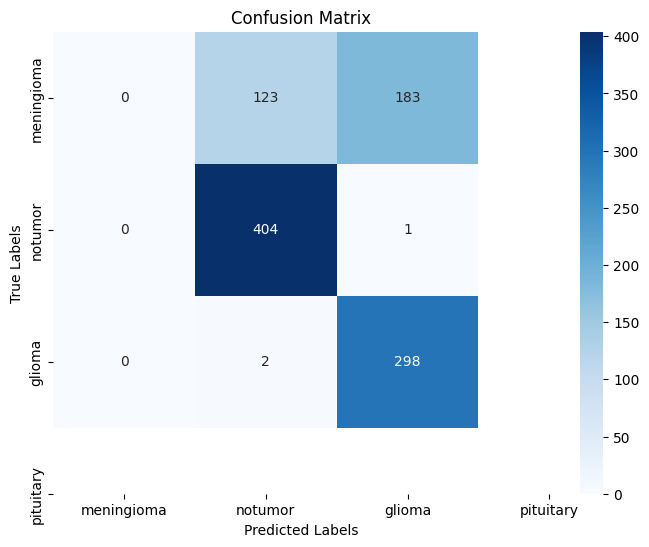

In [ ]:
 #Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

Tumor Detection System

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


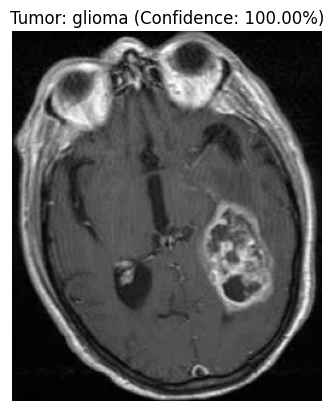

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))
# Example usage
image_path = '/content/drive/MyDrive/MRI/Testing/meningioma/Te-meTr_0001.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


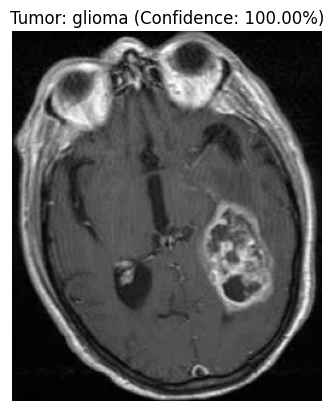

In [ ]:
image_path = '/content/drive/MyDrive/MRI/Testing/meningioma/Te-meTr_0001.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

**MODEL 2:2D CNN**

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam


In [ ]:
IMG_SIZE = 80
BATCH_SIZE = 16
EPOCHS = 5
LR = 0.001

train_dir = '/content/drive/MyDrive/MRI/Training/'
test_dir = '/content/drive/MyDrive/MRI/Testing/'


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=90,
    vertical_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)


In [ ]:
import os

print(os.path.exists('/content/drive/MyDrive/MRI/Training'))

False


In [ ]:
#Load training and testing data
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 2864 images belonging to 4 classes.
Found 1011 images belonging to 4 classes.


In [ ]:
from tensorflow.keras import layers, models

def build_paper_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=4):
    model = models.Sequential()

    # Block 1 — 64 filters
    model.add(layers.Conv2D(64, (2,2), padding='same', activation='relu', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (2,2), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.1))

    # Block 2 — 32 filters
    model.add(layers.Conv2D(32, (2,2), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (2,2), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.1))

    # Block 3 — 16 filters
    model.add(layers.Conv2D(16, (2,2), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(16, (2,2), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.1))

    # Block 4 — 8 filters
    model.add(layers.Conv2D(8, (2,2), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(8, (2,2), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.1))

    # Flatten → Dense
    model.add(layers.Flatten())
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.Dropout(0.1))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

model = build_paper_cnn()
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 80, 80, 64)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 40, 40, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 40, 40, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 20, 16)     │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 20, 20, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 20, 20, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 8)      │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 10, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 8)      │           264 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 244,404 (954.70 KB)

 Trainable params: 243,924 (952.83 KB)

 Non-trainable params: 480 (1.88 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
357/357 ━━━━━━━━━━━━━━━━━━━━ 1371s 4s/step - accuracy: 0.5697 - loss: 1.0377 - val_accuracy: 0.3349 - val_loss: 1.9215
Epoch 2/5
357/357 ━━━━━━━━━━━━━━━━━━━━ 312s 874ms/step - accuracy: 0.7378 - loss: 0.6751 - val_accuracy: 0.6537 - val_loss: 0.8720
Epoch 3/5
357/357 ━━━━━━━━━━━━━━━━━━━━ 304s 850ms/step - accuracy: 0.7687 - loss: 0.5750 - val_accuracy: 0.6606 - val_loss: 0.9592
Epoch 4/5
357/357 ━━━━━━━━━━━━━━━━━━━━ 309s 867ms/step - accuracy: 0.7989 - loss: 0.5240 - val_accuracy: 0.6209 - val_loss: 1.1038
Epoch 5/5
357/357 ━━━━━━━━━━━━━━━━━━━━ 298s 834ms/step - accuracy: 0.8102 - loss: 0.4824 - val_accuracy: 0.4584 - val_loss: 2.0313


In [ ]:
model.save("/content/drive/MyDrive/2d_cnn_model.h5")
print("Model Saved Successfully!")


Model Saved Successfully!


In [ ]:
loss, acc = model.evaluate(test_gen)
print("Test Accuracy: {:.2f}%".format(acc * 100))
print("Test Loss:", loss)


82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.5535 - loss: 1.4316
Test Accuracy: 66.82%
Test Loss: 1.0855625867843628


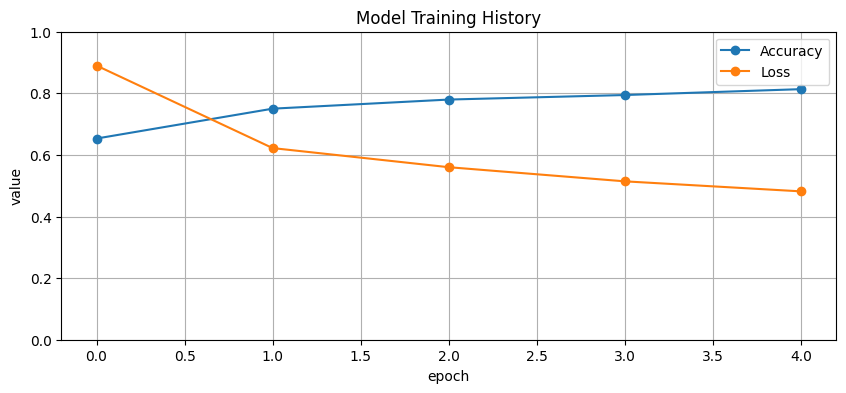

In [ ]:
import matplotlib.pyplot as plt



acc  = history.history['accuracy']
loss = history.history['loss']
epochs = range(len(acc))

plt.figure(figsize=(10,4))
plt.plot(epochs, acc, marker='o', label='Accuracy')
plt.plot(epochs, loss, marker='o', label='Loss')

plt.title('Model Training History')
plt.xlabel('epoch')
plt.ylabel('value')
plt.ylim(0, 1.0)       # kyunki accuracy 0–1 range me hoti hai
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = test_gen.classes
y_prob = model.predict(test_gen)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)


82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.84      0.43      0.57       300
  meningioma       0.60      0.44      0.51       306
     notumor       0.61      1.00      0.75       405
   pituitary       0.79      0.69      0.73       300

    accuracy                           0.67      1311
   macro avg       0.71      0.64      0.64      1311
weighted avg       0.70      0.67      0.65      1311


Confusion Matrix:
 [[130  73  69  28]
 [ 15 136 127  28]
 [  1   0 404   0]
 [  9  19  66 206]]


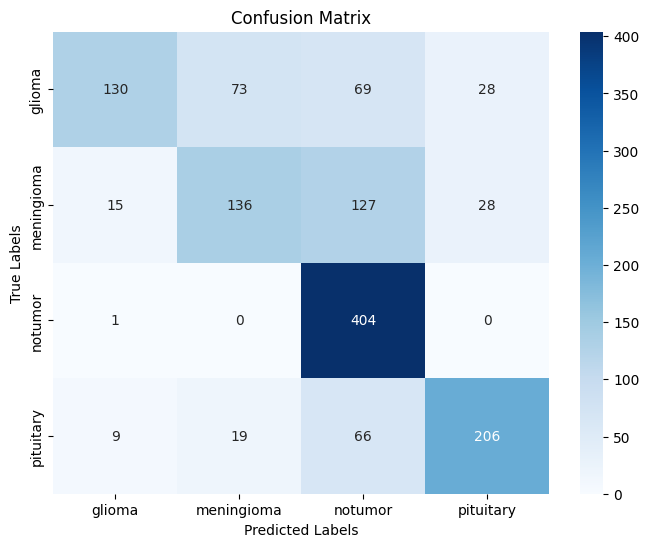

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# class names in correct order (same as your dataset)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.ylabel("True Labels")
plt.xlabel("Predicted Labels")
plt.show()


**MODEL 3:KNN**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_dir = '/content/drive/MyDrive/MRI/Training/'
test_dir  = '/content/drive/MyDrive/MRI/Testing/'

IMG_SIZE = 40
BATCH_SIZE = 32


In [ ]:
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',   # KNN ke liye features kam karne ke liye
    shuffle=False             # very important for labels
)

test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print("Classes:", class_names)


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
# ---------- TRAIN DATA ----------
X_train_list = []
y_train_list = []

for i in range(len(train_gen)):
    x_batch, y_batch = train_gen[i]
    X_train_list.append(x_batch)
    y_train_list.append(y_batch)

X_train = np.concatenate(X_train_list, axis=0)
y_train_onehot = np.concatenate(y_train_list, axis=0)
y_train = np.argmax(y_train_onehot, axis=1)

print("Train:", X_train.shape, y_train.shape)

# ---------- TEST DATA ----------
X_test_list = []
y_test_list = []

for i in range(len(test_gen)):
    x_batch, y_batch = test_gen[i]
    X_test_list.append(x_batch)
    y_test_list.append(y_batch)

X_test = np.concatenate(X_test_list, axis=0)
y_test_onehot = np.concatenate(y_test_list, axis=0)
y_test = np.argmax(y_test_onehot, axis=1)

print("Test:", X_test.shape, y_test.shape)


Train: (5712, 40, 40, 1) (5712,)
Test: (1311, 40, 40, 1) (1311,)


In [ ]:
# (N, 40, 40, 1) → (N, 40*40)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print("Flattened shapes:", X_train_flat.shape, X_test_flat.shape)

# Features ko scale karna KNN ke liye helpful hota hai
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled  = scaler.transform(X_test_flat)


Flattened shapes: (5712, 1600) (1311, 1600)


In [ ]:
# k = 5 (3, 7, 9 try kar sakte ho)
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean',
    weights='distance'   # paas wale points ko zyada weight
)

knn.fit(X_train_scaled, y_train)


KNeighborsClassifier(metric='euclidean', weights='distance')

In [ ]:
y_pred = knn.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print("KNN Test Accuracy: {:.2f}%".format(acc * 100))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


KNN Test Accuracy: 92.14%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.83      0.93      0.88       300
  meningioma       0.93      0.76      0.84       306
     notumor       0.96      0.99      0.97       405
   pituitary       0.96      0.99      0.98       300

    accuracy                           0.92      1311
   macro avg       0.92      0.92      0.92      1311
weighted avg       0.92      0.92      0.92      1311



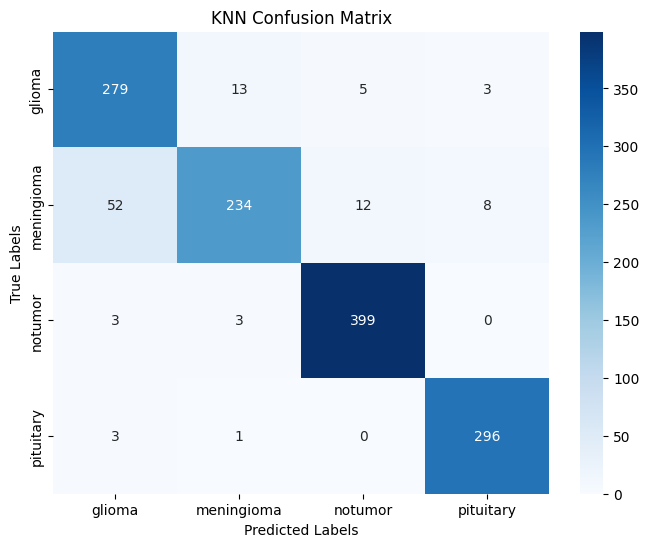

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


In [ ]:
import joblib


joblib.dump(knn, "/content/knn_model.pkl")


joblib.dump(scaler, "/content/knn_scaler.pkl")

print("KNN Model and Scaler Saved Successfully!")


KNN Model and Scaler Saved Successfully!


In [ ]:
!cp /content/knn_model.pkl /content/drive/MyDrive/
!cp /content/knn_scaler.pkl /content/drive/MyDrive/


In [ ]:
import joblib

knn = joblib.load("/content/drive/MyDrive/knn_model.pkl")
scaler = joblib.load("/content/drive/MyDrive/knn_scaler.pkl")

print("KNN model loaded successfully!")


KNN model loaded successfully!


In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# SAME CLASS ORDER YOU USED WHILE TRAINING
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def knn_detect_and_display(img_path, knn_model, scaler, image_size=128):
    """
    Simple KNN Detection Function (Same Style as your VGG detect_and_display)
    Shows image + predicted tumor class + confidence score.
    """

    try:
        # Load image
        img = load_img(img_path, target_size=(image_size, image_size), color_mode='grayscale')
        img_array = img_to_array(img) / 255.0

        # Flatten for KNN
        img_flat = img_array.reshape(1, -1)

        # Scale using saved scaler
        img_scaled = scaler.transform(img_flat)

        # Predict
        probabilities = knn_model.predict_proba(img_scaled)[0]
        predicted_index = np.argmax(probabilities)
        confidence = probabilities[predicted_index]

        predicted_label = class_labels[predicted_index]

        # Logic for "No Tumor"
        if predicted_label == 'notumor':
            result_text = "No Tumor Detected"
        else:
            result_text = f"Tumor: {predicted_label}"

        # Display image with results
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result_text} (Confidence: {confidence * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error:", str(e))


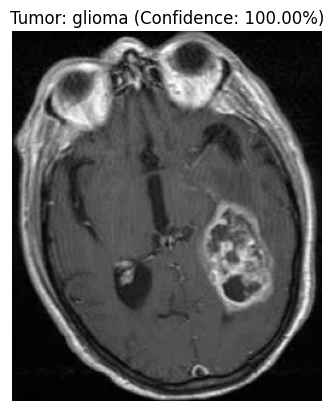

In [ ]:
image_path = "/content/drive/MyDrive/MRI/Testing/meningioma/Te-meTr_0001.jpg"

knn_detect_and_display(image_path, knn, scaler, image_size=40)


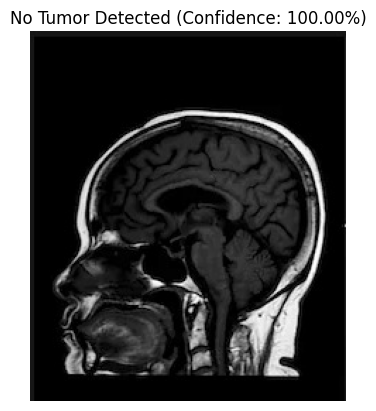

In [ ]:
image_path = "/content/drive/MyDrive/MRI/Testing/notumor/Te-noTr_0004.jpg"

knn_detect_and_display(image_path, knn, scaler, image_size=40)


**MODEL 4** :RESNET

In [ ]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from sklearn.utils import shuffle

In [ ]:
# Model architecture Resnet
IMAGE_SIZE = 224  # Image size (adjust based on your requirements)
base_model = ResNet50(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 5

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 59s 135ms/step - loss: 1.1419 - sparse_categorical_accuracy: 0.5625
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 46s 140ms/step - loss: 0.6661 - sparse_categorical_accuracy: 0.7217
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 40s 142ms/step - loss: 0.5809 - sparse_categorical_accuracy: 0.7619
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 41s 145ms/step - loss: 0.5410 - sparse_categorical_accuracy: 0.7762
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 40s 141ms/step - loss: 0.5233 - sparse_categorical_accuracy: 0.7842


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 17s 263ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.98      0.83       405
           1       0.71      0.77      0.74       300
           2       0.92      0.86      0.89       300
           3       0.63      0.32      0.43       306

    accuracy                           0.75      1311
   macro avg       0.75      0.73      0.72      1311
weighted avg       0.74      0.75      0.73      1311



In [ ]:
# Save the entire model
model.save('model_knn.h5')

In [ ]:
from sklearn.metrics import accuracy_score


y_pred = np.argmax(test_predictions, axis=1)


y_true = test_labels_encoded

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy: {:.2f}%".format(accuracy * 100))


Accuracy: 75.13%


Confusion Matrix:
[[397   1   1   6]
 [ 18 232   6  44]
 [ 24  12 257   7]
 [111  80  16  99]]


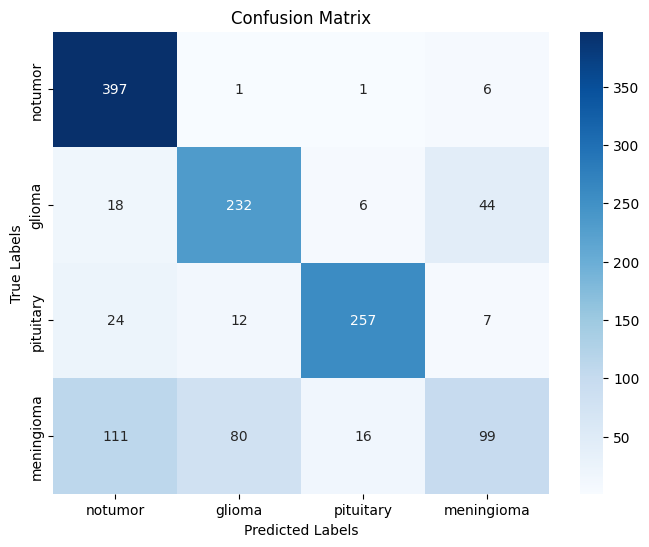

In [ ]:
 #Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [ ]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import DenseNet121
from sklearn.utils import shuffle

In [ ]:
# Model architecture Resnet
IMAGE_SIZE = 224  # Image size (adjust based on your requirements)
base_model = DenseNet121(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 5

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1054s 4s/step - loss: 0.7721 - sparse_categorical_accuracy: 0.7596
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1027s 4s/step - loss: 0.2315 - sparse_categorical_accuracy: 0.9173
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1028s 4s/step - loss: 0.1522 - sparse_categorical_accuracy: 0.9417
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1018s 4s/step - loss: 0.0999 - sparse_categorical_accuracy: 0.9685
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1029s 4s/step - loss: 0.0699 - sparse_categorical_accuracy: 0.9761


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 249s 6s/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       405
           1       0.98      0.86      0.92       300
           2       0.97      0.98      0.98       300
           3       0.87      0.97      0.91       306

    accuracy                           0.95      1311
   macro avg       0.95      0.95      0.95      1311
weighted avg       0.96      0.95      0.95      1311



In [ ]:
model.save("/content/densenet121_model.h5")
print("DenseNet121 model saved successfully!")

DenseNet121 model saved successfully!


In [ ]:
from sklearn.metrics import accuracy_score


y_pred = np.argmax(test_predictions, axis=1)


y_true = test_labels_encoded

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy: {:.2f}%".format(accuracy * 100))


Accuracy: 95.35%


Confusion Matrix:
[[400   0   0   5]
 [  0 259   5  36]
 [  0   0 295   5]
 [  0   5   5 296]]


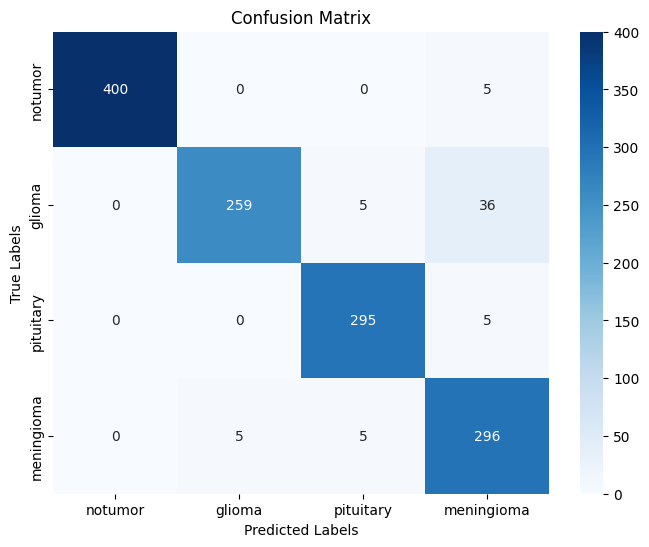

In [ ]:
 #Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

**ENSEMBLE**

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of test images: 1311


✅ Loaded CNN: VGG16 from /content/drive/MyDrive/MRI_models/model.h5


✅ Loaded CNN: CNN2D from /content/drive/MyDrive/MRI_models/2d_cnn_model.h5


✅ Loaded CNN: ResNet50 from /content/drive/MyDrive/MRI_models/model_knn.h5


✅ Loaded CNN: DenseNet121 from /content/drive/MyDrive/MRI_models/densenet121_model.h5
CNN models in ensemble: VGG16, CNN2D, ResNet50, DenseNet121
✅ Loaded KNN model and scaler

Predicting with VGG16 (input size = 224x224) ...
82/82 ━━━━━━━━━━━━━━━━━━━━ 240s 3s/step

Predicting with CNN2D (input size = 80x80) ...
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 142ms/step

Predicting with ResNet50 (input size = 80x80) ...
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 141ms/step

Predicting with DenseNet121 (input size = 224x224) ...
82/82 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step

Predicting with KNN model...
KNN probs shape: (1311, 4)

=== FINAL ENSEMBLE (VGG16 + 2D-CNN + ResNet50 + DenseNet121 + KNN) ===
Accuracy: 87.64%

Classification Report:

              precision    recall  f1-score   support

      glioma       0.84      0.86      0.85       300
  meningioma       0.85      0.69      0.76       306
     notumor       0.88      0.98      0.93       405
   pituitary       0.92      0.94      0.93       300

    accuracy

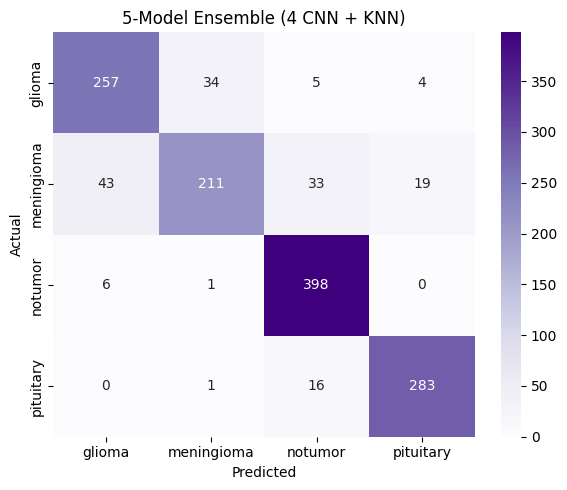

In [ ]:
import os
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import cv2

# ----------------------------------------------------
# 0) Class info from your test generator
# ----------------------------------------------------
class_indices = test_gen.class_indices            # {'glioma':0,...}
idx_to_class = {v: k for k, v in class_indices.items()}
num_classes = len(idx_to_class)
class_names = [idx_to_class[i] for i in range(num_classes)]
print("Classes:", class_names)

test_paths = test_gen.filepaths          # list of image paths
y_true = test_gen.classes                # true labels (N,)

N = len(test_paths)
print("Number of test images:", N)

# ----------------------------------------------------
# 1) Load CNN models from MRI_models folder
# ----------------------------------------------------
SAVE_DIR = "/content/drive/MyDrive/MRI_models"

cnn_paths = {
    "VGG16"      : os.path.join(SAVE_DIR, "model.h5"),
    "CNN2D"      : os.path.join(SAVE_DIR, "2d_cnn_model.h5"),
    "ResNet50"   : os.path.join(SAVE_DIR, "model_knn.h5"),
    "DenseNet121": os.path.join(SAVE_DIR, "densenet121_model.h5"),
}

cnn_models = {}
for name, p in cnn_paths.items():
    try:
        cnn_models[name] = load_model(p)
        print(f"✅ Loaded CNN: {name} from {p}")
    except Exception as e:
        print(f"⚠️ Could not load {name} at {p}: {e}")

assert len(cnn_models) >= 2, "Need at least two CNN models for an ensemble."
cnn_names = list(cnn_models.keys())
print("CNN models in ensemble:", ", ".join(cnn_names))

# ----------------------------------------------------
# 2) Load KNN model + scaler
# ----------------------------------------------------
knn_path = os.path.join(SAVE_DIR, "knn_model.pkl")
scaler_path = os.path.join(SAVE_DIR, "knn_scaler.pkl")  # change name if needed

knn_model = joblib.load(knn_path)
knn_scaler = joblib.load(scaler_path)
print("✅ Loaded KNN model and scaler")

KNN_IMG_SIZE = 40  # the size you used when training KNN

def preprocess_for_knn(img_path, size=KNN_IMG_SIZE):
    """Read image as grayscale, resize, flatten, scale for KNN."""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (size, size))
    img = img.astype("float32") / 255.0
    flat = img.reshape(1, -1)        # (1, size*size)
    flat_scaled = knn_scaler.transform(flat)
    return flat_scaled

# ----------------------------------------------------
# 3) CNN probabilities for all test images
#    (each model uses its OWN input size)
# ----------------------------------------------------
cnn_probs_list = []

for name in cnn_names:
    model = cnn_models[name]
    h, w = model.input_shape[1], model.input_shape[2]   # model-specific size
    print(f"\nPredicting with {name} (input size = {h}x{w}) ...")

    imgs = []
    for path in test_paths:
        img = load_img(path, target_size=(h, w))
        x = img_to_array(img) / 255.0
        imgs.append(x)
    X = np.array(imgs)                                  # (N,h,w,3)

    pr = model.predict(X, batch_size=16, verbose=1)     # (N, num_classes)
    cnn_probs_list.append(pr)

cnn_probs = np.stack(cnn_probs_list, axis=0)            # (num_cnn, N, num_classes)
cnn_probs_mean = cnn_probs.mean(axis=0)                 # (N, num_classes)

# ----------------------------------------------------
# 4) KNN probabilities on the SAME test images
# ----------------------------------------------------
print("\nPredicting with KNN model...")
knn_probs_list = []

for path in test_paths:
    x_knn = preprocess_for_knn(path)                    # (1, features)
    p_knn = knn_model.predict_proba(x_knn)[0]           # (num_classes,)
    knn_probs_list.append(p_knn)

knn_probs = np.array(knn_probs_list)                    # (N, num_classes)
print("KNN probs shape:", knn_probs.shape)

# ----------------------------------------------------
# 5) FINAL 5-MODEL ENSEMBLE (4 CNN + 1 KNN)
# ----------------------------------------------------
all_probs = np.stack([cnn_probs_mean, knn_probs], axis=0)  # (2, N, num_classes)
ensemble_probs = all_probs.mean(axis=0)                     # (N, num_classes)

y_pred = np.argmax(ensemble_probs, axis=1)

# ----------------------------------------------------
# 6) Metrics
# ----------------------------------------------------
print("\n=== FINAL ENSEMBLE (VGG16 + 2D-CNN + ResNet50 + DenseNet121 + KNN) ===")
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc*100:.2f}%\n")

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Purples',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("5-Model Ensemble (4 CNN + KNN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


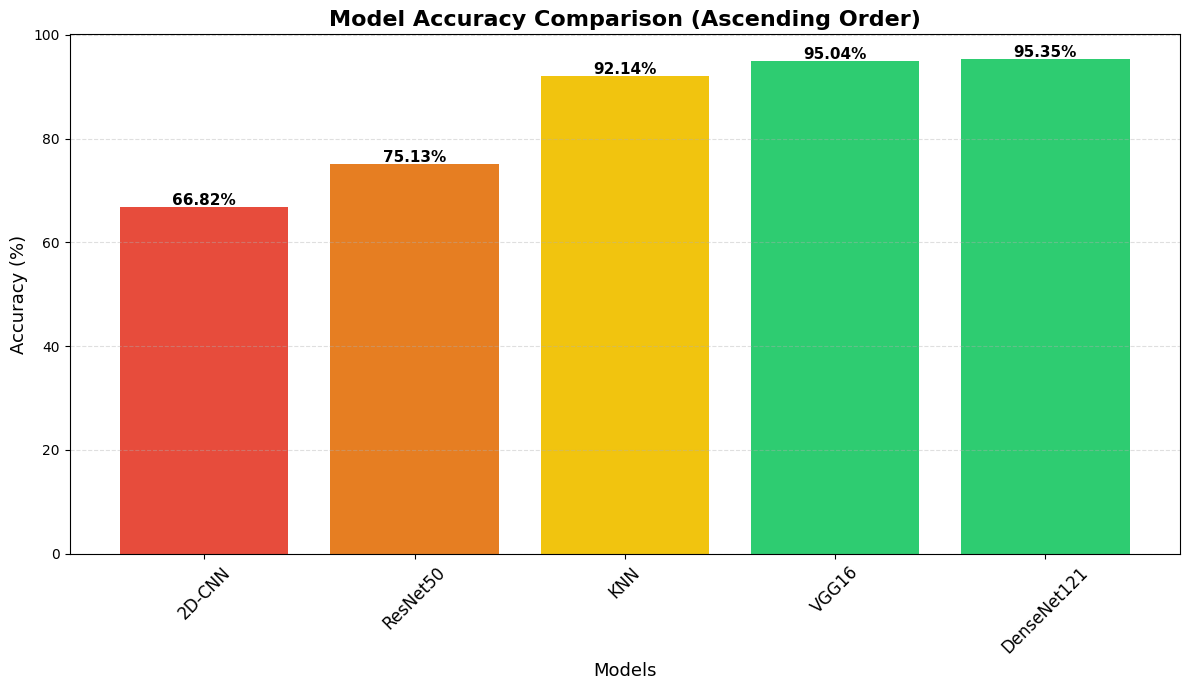

In [ ]:
import matplotlib.pyplot as plt

# Your accuracies
models = ["VGG16", "2D-CNN", "KNN", "ResNet50", "DenseNet121"]
accuracies = [95.04, 66.82, 92.14, 75.13, 95.35]

# Combine models + accuracies, then sort by accuracy ASCENDING
combined = sorted(zip(models, accuracies), key=lambda x: x[1])

sorted_models = [x[0] for x in combined]
sorted_accs = [x[1] for x in combined]

# Assign colors based on accuracy
colors = []
for acc in sorted_accs:
    if acc >= 95:
        colors.append("#2ecc71")    # Green (best)
    elif acc >= 85:
        colors.append("#f1c40f")    # Yellow
    elif acc >= 70:
        colors.append("#e67e22")    # Orange
    else:
        colors.append("#e74c3c")    # Red (lowest)

plt.figure(figsize=(12, 7))

# Bar plot
bars = plt.bar(sorted_models, sorted_accs, color=colors)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.4,
        f"{height:.2f}%",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Titles and labels
plt.title("Model Accuracy Comparison (Ascending Order)", fontsize=16, fontweight='bold')
plt.xlabel("Models", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.xticks(rotation=45, fontsize=12)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
